In [3]:
import pandas as pd
import numpy as np 
import keras
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error 
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import joblib # Para salvar os normalizadores


In [4]:
def create_delta_data(local_data):
    OriginalData = pd.read_csv(local_data)
    OriginalData.index = (np.arange(0, len(OriginalData), 1).astype(float) * 0.07).round(5)
    OriginalData = OriginalData.drop(columns=["x(Wd,We)", "y(Wd,We)", "tempo"])
    theta = OriginalData["theta(Wd,We)"].to_numpy()
    theta_0 = theta[:-1]
    theta_1 = theta[1:]
    delta_theta = (theta_1 - theta_0) / 0.07
    wd_alinhado = OriginalData['Wd'].iloc[:-1]  
    we_alinhado = OriginalData['We'].iloc[:-1] 
    wd_true_alinhado = OriginalData['Wd_true'].iloc[:-1]
    we_true_alinhado = OriginalData['We_true'].iloc[:-1]
    df_new = pd.DataFrame({
        'Wd': wd_alinhado,
        'We': we_alinhado,
        'delta_theta': delta_theta,
        'Wd_true': wd_true_alinhado,
        'We_true': we_true_alinhado
    })
    print(df_new.head())
    print("Shape do novo_df:", df_new.shape)
    return df_new

TrainData = create_delta_data("./Dados/DataSmoothSpline1.csv")
TestData = create_delta_data("./Dados/DataSmoothSpline3.csv")
ValData = create_delta_data("./Dados/DataSmoothSpline2.csv")


            Wd        We  delta_theta   Wd_true   We_true
0.00  2.046979  2.067159     0.004965  0.163271  0.093873
0.07  2.058519  2.079836     0.004959  0.242458  0.175944
0.14  2.069982  2.092437     0.004942  0.321637  0.258010
0.21  2.081302  2.104891     0.004909  0.400792  0.340061
0.28  2.092419  2.117138     0.004853  0.479896  0.422075
Shape do novo_df: (2145, 5)
            Wd        We  delta_theta   Wd_true   We_true
0.00  2.250967  2.289211     0.008868  0.204149  0.077678
0.07  2.246293  2.286558     0.008856  0.283600  0.162385
0.14  2.241624  2.283906     0.008824  0.363042  0.247087
0.21  2.236964  2.281260     0.008762  0.442455  0.331776
0.28  2.232324  2.278624     0.008659  0.521806  0.416432
Shape do novo_df: (2026, 5)
            Wd        We  delta_theta   Wd_true   We_true
0.00  1.866241  1.950911     0.007093  0.118729 -0.110797
0.07  1.870389  1.957288     0.007070  0.187222 -0.030969
0.14  1.874468  1.963593     0.007006  0.255708  0.048863
0.21  1.878425  

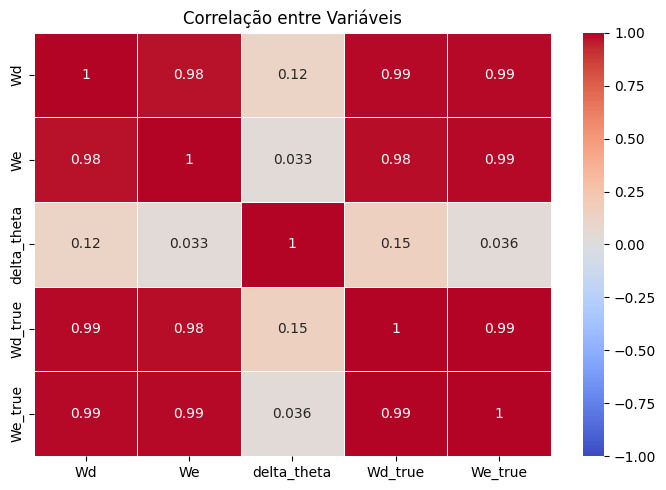

In [15]:
# Selecione apenas colunas numéricas
numeric_cols = TrainData.select_dtypes(include=[np.number]).columns
corr_matrix = TrainData[numeric_cols].corr()

# Criar mapa de calor
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlação entre Variáveis')
plt.tight_layout()
plt.show()

In [16]:
# Define predictors and target
PREDICTORS = ["Wd", "We"]
TARGET = "delta_theta"

# Convertendo para arrays numpy
train_x = TrainData[PREDICTORS].to_numpy()
train_y = TrainData[[TARGET]].to_numpy()
print(train_x.shape)

x_val = ValData[PREDICTORS].to_numpy()
y_val = ValData[[TARGET]].to_numpy()

x_test = TestData[PREDICTORS].to_numpy()
y_test = TestData[[TARGET]].to_numpy()


x_scaler = MinMaxScaler(feature_range=(-1, 1))
y_scaler = MinMaxScaler(feature_range=(-1, 1))

print("\nAjustando os normalizadores (scalers) com os dados de treino...")
x_scaler.fit(train_x)
y_scaler.fit(train_y)

joblib.dump(x_scaler, 'x_scaler.gz')
joblib.dump(y_scaler, 'y_scaler.gz')
print("Normalizadores salvos como 'x_scaler.gz' e 'y_scaler.gz'")

# AGORA, TRANSFORME TODOS OS CONJUNTOS DE DADOS com os scalers já ajustados
train_x_norm = x_scaler.transform(train_x)
train_y_norm = y_scaler.transform(train_y)

x_val_norm = x_scaler.transform(x_val)
y_val_norm = y_scaler.transform(y_val)

x_test_norm = x_scaler.transform(x_test)
y_test_norm = y_scaler.transform(y_test)


print("\nShape de X_train depois da normalização:", train_x_norm.shape)
print("Primeiras linhas de X_train normalizado:\n", train_x_norm[:5])
print("\nPrimeiras linhas de y_train normalizado:\n", train_y_norm[:5])




(2145, 2)

Ajustando os normalizadores (scalers) com os dados de treino...
Normalizadores salvos como 'x_scaler.gz' e 'y_scaler.gz'

Shape de X_train depois da normalização: (2145, 2)
Primeiras linhas de X_train normalizado:
 [[0.84617662 0.86253703]
 [0.85097515 0.86788632]
 [0.85574195 0.87320305]
 [0.86044886 0.87845795]
 [0.86507184 0.8836256 ]]

Primeiras linhas de y_train normalizado:
 [[0.07529811]
 [0.07527054]
 [0.07519498]
 [0.07504621]
 [0.07479823]]



Gerando gráficos de histograma de densidade...


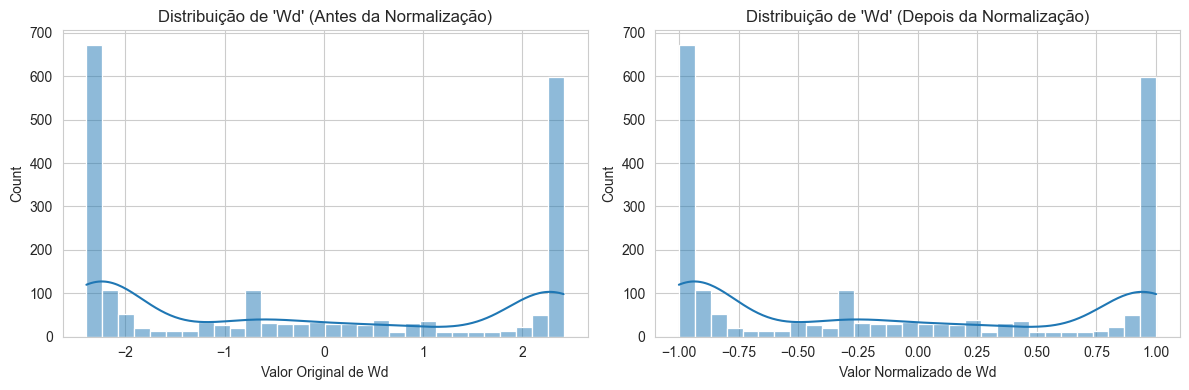

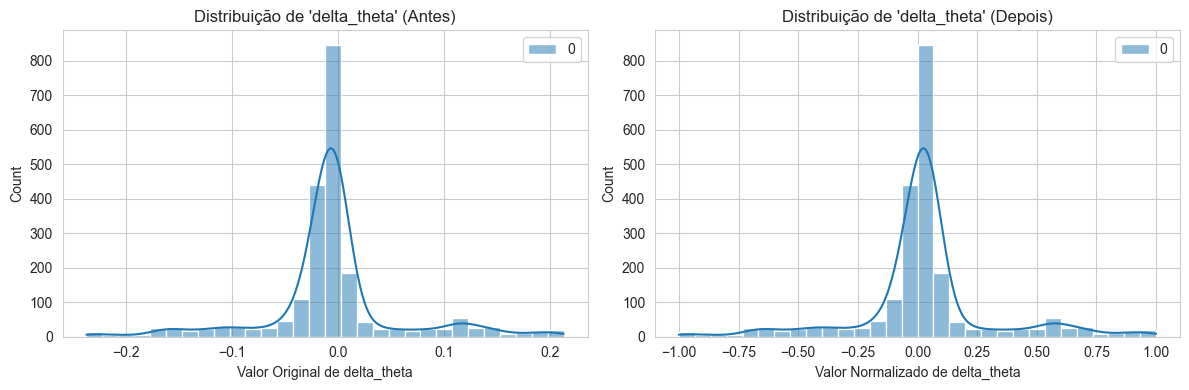


Gerando gráficos de dispersão...


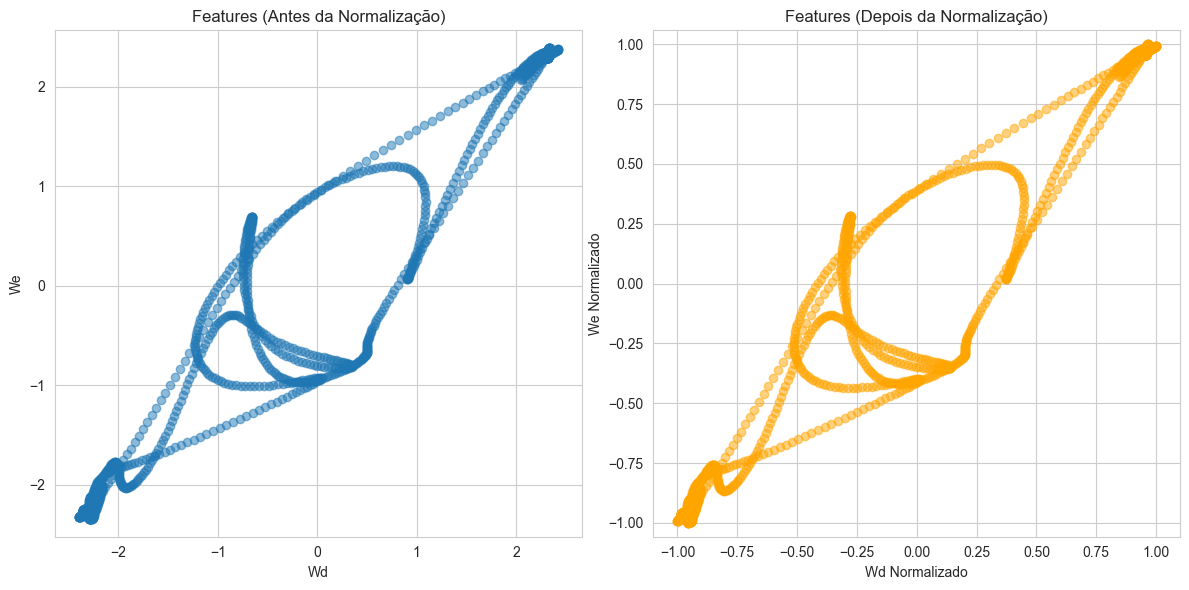


Gerando gráficos de linha...


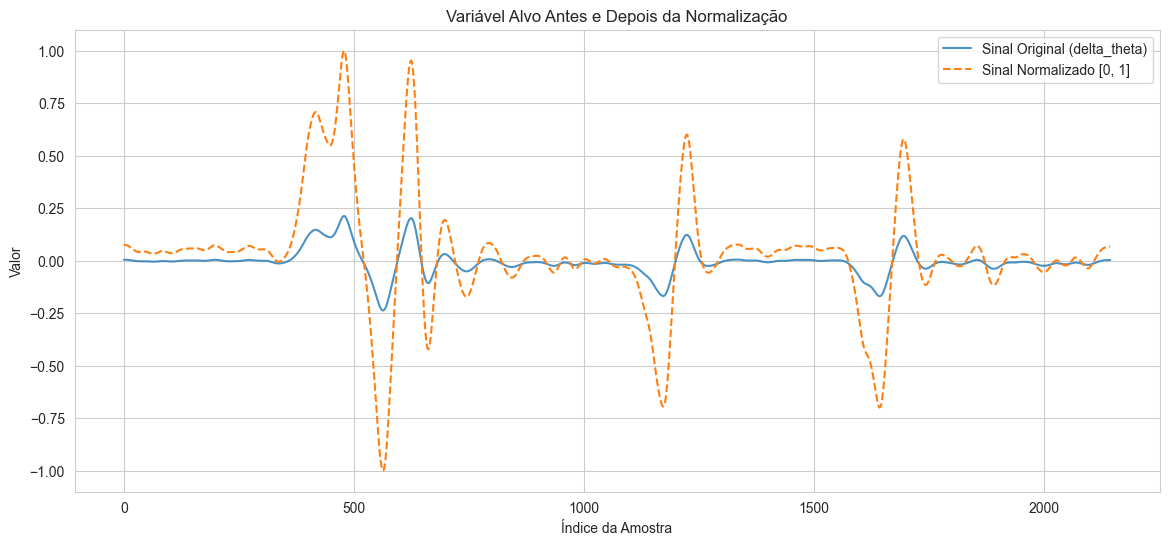

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configura um estilo visual mais agradável para os gráficos
sns.set_style("whitegrid")

# --------------------------------------------------------------------------
# Visualização 1: Histogramas de Densidade (para cada variável)
# --------------------------------------------------------------------------
# Esta visualização é ótima para ver como a escala de uma única variável muda,
# mas sua distribuição de formato se mantém.

print("\nGerando gráficos de histograma de densidade...")

# Comparando a primeira feature: 'Wd'
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_x[:, 0], kde=True, ax=axs[0], bins=30)
axs[0].set_title("Distribuição de 'Wd' (Antes da Normalização)")
axs[0].set_xlabel("Valor Original de Wd")

sns.histplot(train_x_norm[:, 0], kde=True, ax=axs[1], bins=30)
axs[1].set_title("Distribuição de 'Wd' (Depois da Normalização)")
axs[1].set_xlabel("Valor Normalizado de Wd")
plt.tight_layout()
plt.show()

# Comparando a variável alvo: 'delta_theta'
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_y, kde=True, ax=axs[0], bins=30)
axs[0].set_title("Distribuição de 'delta_theta' (Antes)")
axs[0].set_xlabel("Valor Original de delta_theta")


sns.histplot(train_y_norm, kde=True, ax=axs[1], bins=30)
axs[1].set_title("Distribuição de 'delta_theta' (Depois)")
axs[1].set_xlabel("Valor Normalizado de delta_theta")
plt.tight_layout()
plt.show()


# --------------------------------------------------------------------------
# Visualização 2: Gráfico de Dispersão (Scatter Plot) para as Features (X)
# --------------------------------------------------------------------------
# Este gráfico mostra como a relação entre 'Wd' e 'We' é preservada,
# enquanto a nuvem de pontos é reescalada para o quadrado [0, 1] x [0, 1].

print("\nGerando gráficos de dispersão...")

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].scatter(train_x[:, 0], train_x[:, 1], alpha=0.5)
axs[0].set_xlabel('Wd')
axs[0].set_ylabel('We')
axs[0].set_title('Features (Antes da Normalização)')
axs[0].grid(True)
axs[0].axis('equal') # Tenta manter a mesma escala nos eixos

axs[1].scatter(train_x_norm[:, 0], train_x_norm[:, 1], alpha=0.5, color='orange')
axs[1].set_xlabel('Wd Normalizado')
axs[1].set_ylabel('We Normalizado')
axs[1].set_title('Features (Depois da Normalização)')
axs[1].grid(True)
axs[1].set_xlim(-0.1, 1.1) # Limites para visualizar melhor o quadrado [0,1]
axs[1].set_ylim(-0.1, 1.1)
axs[1].axis('equal')
plt.tight_layout()
plt.show()

# --------------------------------------------------------------------------
# Visualização 3: Gráfico de Linha para a Variável Alvo (y)
# --------------------------------------------------------------------------
# Se seus dados são uma série temporal, esta visualização mostra como o padrão
# ao longo do tempo é preservado, mudando apenas a amplitude do sinal.

print("\nGerando gráficos de linha...")

plt.figure(figsize=(14, 6))
plt.plot(train_y, label='Sinal Original (delta_theta)', alpha=0.8)
plt.plot(train_y_norm, label='Sinal Normalizado [0, 1]', linestyle='--')
plt.title('Variável Alvo Antes e Depois da Normalização')
plt.xlabel('Índice da Amostra')
plt.ylabel('Valor')
plt.legend()
plt.show()

In [14]:
import os
import random

#os.environ['PYTHONHASHSEED'] = '47'
#os.environ['TF_DETERMINISTIC_OPS'] = '1'  # força operações determinísticas no TF (em CPU/GPU)
#random.seed(47)
#np.random.seed(47)
#tf.random.set_seed(47)



Tamanho do batch: 2145


c:\Users\João Vitor\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - attempts: 1.0000 - damping_factor: 1.0000e-04 - loss: 0.0644 - val_loss: 0.1150
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - attempts: 2.0000 - damping_factor: 1.0000e-04 - loss: 0.0638 - val_loss: 0.1134
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - attempts: 2.0000 - damping_factor: 1.0000e-04 - loss: 0.0631 - val_loss: 0.1130
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - attempts: 2.0000 - damping_factor: 1.0000e-04 - loss: 0.0629 - val_loss: 0.1129
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - attempts: 2.0000 - damping_factor: 1.0000e-04 - loss: 0.0628 - val_loss: 0.1129
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - attempts: 2.0000 - damping_factor: 1.0000e-04 - loss: 0.0627 - val_loss: 0.1129
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - attempts: 2.0000 - damping_factor: 1.0000e-04 - loss: 0.0625 - val_loss: 0.1130
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - attempts: 2.0000 - 

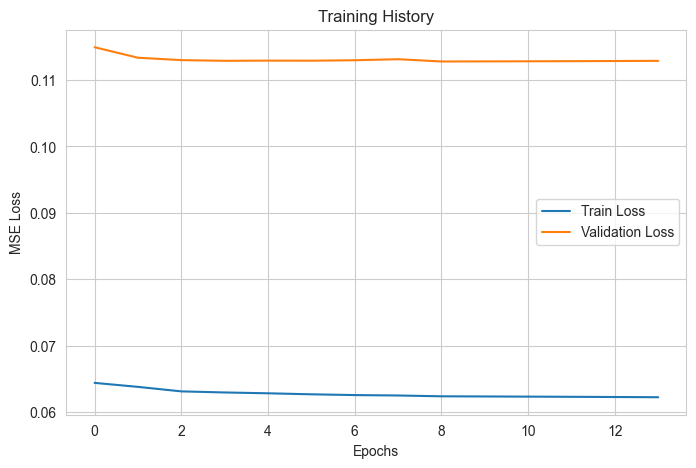

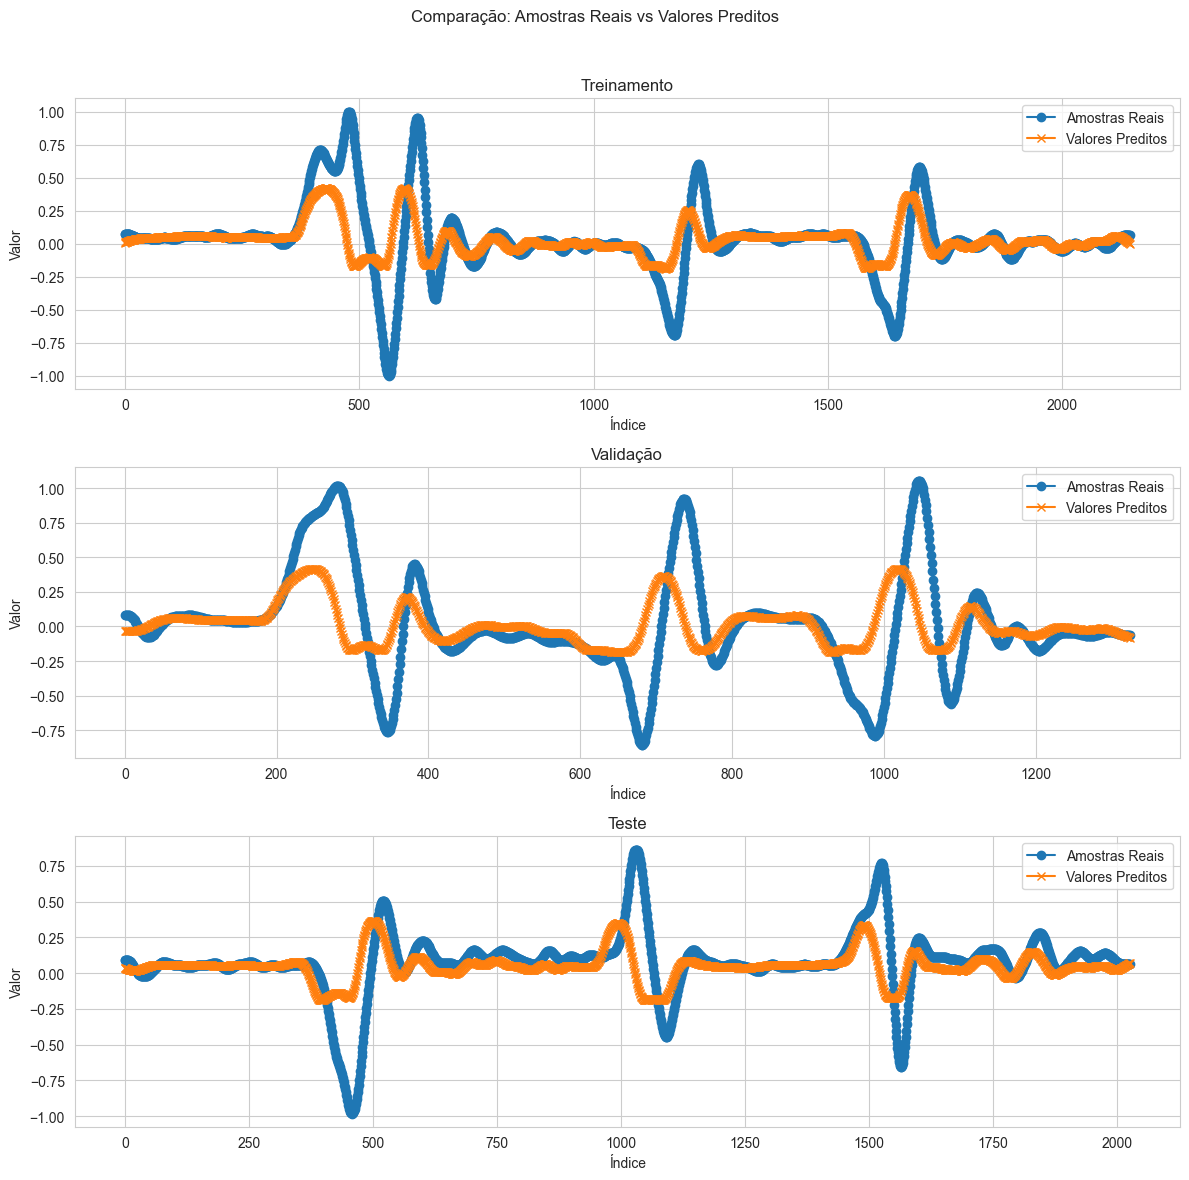

In [18]:
import tf_levenberg_marquardt as lm
from tensorflow.keras.callbacks import EarlyStopping

early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=5,
    min_delta=0,
    restore_best_weights=True,
    verbose=1
)

model = keras.Sequential([
    keras.layers.Dense(20, activation='tanh', input_shape=(len(PREDICTORS),)),
    keras.layers.Dense(10, activation='tanh'),
    keras.layers.Dense(1)
])

model_wrapper = lm.model.ModelWrapper(keras.models.clone_model(model))

model_wrapper.compile(
    optimizer=keras.optimizers.SGD(learning_rate=1.0), loss=lm.loss.MeanSquaredError()
)
BATCH = len(train_x_norm)
history = model_wrapper.fit(train_x_norm, train_y_norm, epochs=100, validation_data=(x_val_norm, y_val_norm),batch_size=BATCH ,verbose=True, callbacks=[early_stopping_callback])

print(model_wrapper.history.history.keys())
# Previsões
train_pred = model_wrapper.predict(train_x_norm) 
val_pred = model_wrapper.predict(x_val_norm)
test_pred = model_wrapper.predict(x_test_norm)
# Cálculo das métricas  
metrics = {
    'Training': {
        'R2': r2_score(train_y_norm, train_pred),
        'MSE': mean_squared_error(train_y_norm, train_pred),
        'RMSE': root_mean_squared_error(train_y_norm, train_pred),
        'MAPE': mean_absolute_percentage_error(train_y_norm, train_pred)
    },
    'Validation': {
        'R2': r2_score(y_val_norm, val_pred),
        'MSE': mean_squared_error(y_val_norm, val_pred),
        'RMSE': root_mean_squared_error(y_val_norm, val_pred),
        'MAPE': mean_absolute_percentage_error(y_val_norm, val_pred)
    },
    'Test': {
        'R2': r2_score(y_test_norm, test_pred),
        'MSE': mean_squared_error(y_test_norm, test_pred),
        'RMSE': root_mean_squared_error(y_test_norm, test_pred),
        'MAPE': mean_absolute_percentage_error(y_test_norm, test_pred)
    }
}
# Imprime as métricas
for name, m in metrics.items():
    print(f"\n{name} Metrics:")
    for k, v in m.items():
        print(f"  {k}: {v:.4f}")
# Gráfico do histórico de treinamento
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Training History')
plt.legend()
plt.grid(True)
plt.show()
# Gráficos comparativos
fig, axs = plt.subplots(3, 1, figsize=(12, 12))
datasets = [
    ('Treinamento', train_y_norm, train_pred),
    ('Validação', y_val_norm, val_pred),
    ('Teste', y_test_norm, test_pred)
]
for i, (title, y_true, y_pred) in enumerate(datasets):
    y_true = np.ravel(y_true)
    y_pred = np.ravel(y_pred)
    axs[i].plot(y_true, marker='o', label='Amostras Reais')
    axs[i].plot(y_pred, marker='x', label='Valores Preditos')
    axs[i].set_title(f'{title}')
    axs[i].set_xlabel('Índice')
    axs[i].set_ylabel('Valor')
    axs[i].legend()
    axs[i].grid(True)
plt.suptitle('Comparação: Amostras Reais vs Valores Preditos')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()




In [19]:
def root_mean_squared_error(y_true, y_pred):
    y_true_np = y_true.numpy() if hasattr(y_true, 'numpy') else y_true
    y_pred_np = y_pred.numpy() if hasattr(y_pred, 'numpy') else y_pred
    return np.sqrt(mean_squared_error(y_true_np, y_pred_np))

def custom_train_model_with_es_physics(model,
                                       train_x, train_y,
                                       x_val, y_val,
                                       x_test, y_test,
                                       restrictions_data,
                                       Ts, L, R,
                                       y_scaler,
                                       lambda1=1.0, lambda2=1.0,
                                       epochs=5000, patience=50,
                                       min_delta=0, plot=True,
                                       learning_rate=0.001, use_early_stopping=True):
    """
    Treina um modelo Keras com Adam + Early Stopping e adiciona um termo
    físico MSE_f na loss:

        MSE_f = mean( ((y[k] - y[k-1]) / Ts - (R/L)*(Wd[k-1] - We[k-1]))^2 )

    Loss = lambda1 * MSE_d + lambda2 * MSE_f
    """

    # converter para tf.Tensor float32
    def to_tensor(x):
        return tf.constant(x, dtype=tf.float32) if not tf.is_tensor(x) else tf.cast(x, tf.float32)
    train_x = to_tensor(train_x); train_y = to_tensor(train_y)
    x_val   = to_tensor(x_val);   y_val   = to_tensor(y_val)
    x_test  = to_tensor(x_test);  y_test  = to_tensor(y_test)
    #restrictions_data = to_tensor(restrictions_data)

    optimizer = Adam(learning_rate=learning_rate)
    mse_loss  = MeanSquaredError()

    train_hist, val_hist = [], []
    best_val, wait, best_w = float('inf'), 0, None

    print(f"Treinando com Ts={Ts}, L={L}, R={R}, λ1={lambda1}, λ2={lambda2}")
    for epoch in range(1, epochs+1):
        with tf.GradientTape() as tape:
            # 1) predições
            y_pred = model(train_x, training=True)  # shape [N,1]

            # 2) termo convencional MSE_d
            MSE_d = mse_loss(train_y, y_pred)

            # 3) termo físico MSE_f
            # descartamos o primeiro ponto: predições[1:], predições[:-1]
            #y_k   = y_pred[1:]
            #y_km1 = y_pred[:-1]
            # entradas correspondentes Wd, We no instante k-1
            x1_km1 = restrictions_data[:, 0]   # Wd
            x2_km1 = restrictions_data[:, 1]   # We
            #x1_km1 = train_x[:, 0]  # Wd
            #x2_km1 = train_x[:, 1]  # We
            # calcula derivada aproximada
            #dy_dt = (y_k - y_km1) / Ts
            phys_real  = ((R / L) * (x1_km1 - x2_km1)) 

            phys_real = phys_real.reshape((-1, 1))  # shape [N-1, 1]
            phys_norm = y_scaler.transform(phys_real)
            MSE_f = tf.reduce_mean(tf.square(y_pred - phys_norm))

            # 4) loss total
            loss = lambda1 * MSE_d + lambda2 * MSE_f

        # grads e atualização
        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))

        # validação
        yv = model(x_val, training=False)
        val_d = mse_loss(y_val, yv)
        # para simplicidade não calculo val_f

        train_hist.append(loss.numpy())
        val_hist.append(val_d.numpy())

        if use_early_stopping:
        # early stopping
            if val_d.numpy() < best_val - min_delta:
                best_val = val_d.numpy(); wait = 0
                best_w = model.get_weights()
            else:
                wait += 1

            if wait >= patience:
                print(f"Early stopping na época {epoch}")
                model.set_weights(best_w)
                break

        if epoch % 50 == 0 or epoch == 1:
            print(f"Epoch {epoch}: Loss={loss.numpy():.4g}, MSE_d={MSE_d.numpy():.4g}, MSE_f={MSE_f.numpy():.4g}, Val MSE={val_d.numpy():.4g}")

    # avaliando métricas finais
    def eval_metrics(x, y):
        yp = model(x, training=False)
        y_np, yp_np = y.numpy(), yp.numpy()
        return {
            'R2': r2_score(y_np, yp_np),
            'MSE': mean_squared_error(y_np, yp_np),
            'RMSE': root_mean_squared_error(y_np, yp_np),
            'MAPE': mean_absolute_percentage_error(y_np, yp_np)
        }

    metrics = {
        'Training':   eval_metrics(train_x, train_y),
        'Validation': eval_metrics(x_val,   y_val),
        'Test':       eval_metrics(x_test,  y_test),
    }

    for split, m in metrics.items():
        print(f"\n{split} Metrics:")
        for k, v in m.items():
            print(f"  {k}: {v:.4g}")
            
    train_pred = model.predict(train_x)
    val_pred = model.predict(x_val)
    test_pred = model.predict(x_test)

    # CORREÇÃO: Conversão robusta para arrays numpy para cálculo de métricas sklearn
    # Usamos hasattr(var, 'numpy') para verificar se é um Tensor antes de chamar .numpy()
    train_y_np = train_y.numpy() if hasattr(train_y, 'numpy') else train_y
    train_pred_np = train_pred.numpy() if hasattr(train_pred, 'numpy') else train_pred
    y_val_np = y_val.numpy() if hasattr(y_val, 'numpy') else y_val
    val_pred_np = val_pred.numpy() if hasattr(val_pred, 'numpy') else val_pred
    y_test_np = y_test.numpy() if hasattr(y_test, 'numpy') else y_test
    test_pred_np = test_pred.numpy() if hasattr(test_pred, 'numpy') else test_pred
    # opcional: plot de loss
    if plot:
        plt.plot(train_hist, label='Train Loss')
        plt.plot(val_hist,   label='Val MSE_d')
        plt.xlabel('Epoch'); plt.ylabel('Loss')
        plt.legend(); plt.grid(True)
        plt.show()

        # Gráficos comparativos
        fig, axs = plt.subplots(3, 1, figsize=(12, 12))
        datasets = [
            ('Treinamento', train_y_np, train_pred_np), 
            ('Validação', y_val_np, val_pred_np),
            ('Teste', y_test_np, test_pred_np)
        ]

        for i, (title, y_true, y_pred) in enumerate(datasets):
            y_true_flat = np.ravel(y_true)
            y_pred_flat = np.ravel(y_pred)
            axs[i].plot(y_true_flat, marker='o', label='Amostras Reais')
            axs[i].plot(y_pred_flat, marker='x', label='Valores Preditos')
            axs[i].set_title(f'{title}')
            axs[i].set_xlabel('Índice')
            axs[i].set_ylabel('Valor')
            axs[i].legend()
            axs[i].grid(True)

        plt.suptitle('Comparação: Amostras Reais vs Valores Preditos')
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

        #print(model.trainable_variables)

    return metrics

In [20]:

RESTRICTIONS = ["Wd_true", "We_true"]


Restrictions_data = TrainData[RESTRICTIONS].to_numpy()

restric_norm = x_scaler.transform(Restrictions_data)


print("\nShape de Restrictions_data:", Restrictions_data.shape)
print("Primeiras linhas de Restrictions_data:\n", Restrictions_data[:5])


Shape de Restrictions_data: (2145, 2)
Primeiras linhas de Restrictions_data:
 [[0.16327083 0.0938734 ]
 [0.24245778 0.17594412]
 [0.32163697 0.25801016]
 [0.40079243 0.34006069]
 [0.47989594 0.42207508]]


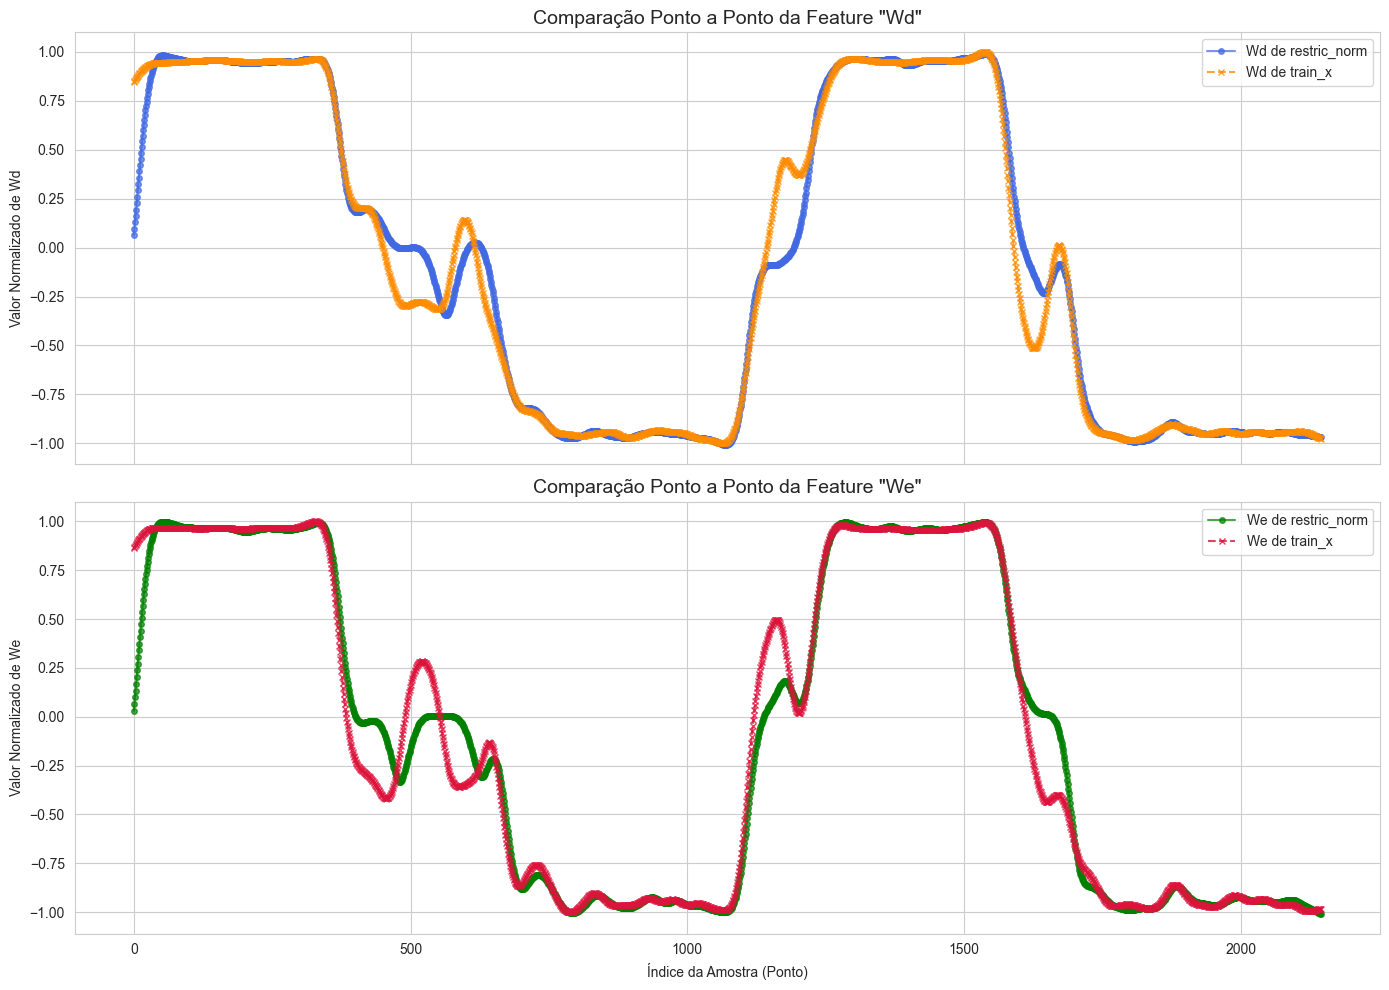

In [21]:

# Criando a figura que conterá os dois gráficos
fig, axs = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# --- Gráfico 1: Comparação dos valores de 'Wd' ---

# Plotando 'Wd' de restric_norm
axs[0].plot(restric_norm[:, 0],    # Feature 'Wd'
            label='Wd de restric_norm',
            color='royalblue',
            marker='o',             # Adiciona um marcador em cada ponto
            linestyle='-',          # Linha conectando os pontos
            markersize=4,
            alpha=0.7)

# Plotando 'Wd' de train_x_pinn_norm
axs[0].plot(train_x_norm[:, 0], # Feature 'Wd'
            label='Wd de train_x',
            color='darkorange',
            marker='x',
            linestyle='--',
            markersize=5,
            alpha=0.8)

axs[0].set_title('Comparação Ponto a Ponto da Feature "Wd"', fontsize=14)
axs[0].set_ylabel('Valor Normalizado de Wd')
axs[0].legend()
axs[0].grid(True)


# --- Gráfico 2: Comparação dos valores de 'We' ---

# Plotando 'We' de restric_norm
axs[1].plot(restric_norm[:, 1],    # Feature 'We'
            label='We de restric_norm',
            color='green',
            marker='o',
            linestyle='-',
            markersize=4,
            alpha=0.7)

# Plotando 'We' de train_x_pinn_norm
axs[1].plot(train_x_norm[:, 1], # Feature 'We'
            label='We de train_x',
            color='crimson',
            marker='x',
            linestyle='--',
            markersize=5,
            alpha=0.8)

axs[1].set_title('Comparação Ponto a Ponto da Feature "We"', fontsize=14)
axs[1].set_ylabel('Valor Normalizado de We')
axs[1].set_xlabel('Índice da Amostra (Ponto)')
axs[1].legend()
axs[1].grid(True)

# Ajusta o layout para evitar sobreposição de títulos
plt.tight_layout()
plt.show()

Treinando com Ts=0.07, L=0.123, R=0.034, λ1=1, λ2=1
Epoch 1: Loss=2.154, MSE_d=1.077, MSE_f=1.076, Val MSE=0.7455
Epoch 50: Loss=0.1446, MSE_d=0.07212, MSE_f=0.07246, Val MSE=0.1287
Epoch 100: Loss=0.1351, MSE_d=0.06716, MSE_f=0.06792, Val MSE=0.1216
Epoch 150: Loss=0.1315, MSE_d=0.06516, MSE_f=0.06631, Val MSE=0.1171
Epoch 200: Loss=0.1304, MSE_d=0.06452, MSE_f=0.06592, Val MSE=0.1152
Epoch 250: Loss=0.1303, MSE_d=0.06438, MSE_f=0.06589, Val MSE=0.1146
Epoch 300: Loss=0.1302, MSE_d=0.06435, MSE_f=0.06589, Val MSE=0.1144
Epoch 350: Loss=0.1302, MSE_d=0.06433, MSE_f=0.06589, Val MSE=0.1144
Epoch 400: Loss=0.1302, MSE_d=0.06433, MSE_f=0.06588, Val MSE=0.1144
Epoch 450: Loss=0.1302, MSE_d=0.06432, MSE_f=0.06587, Val MSE=0.1143
Epoch 500: Loss=0.1302, MSE_d=0.06431, MSE_f=0.06586, Val MSE=0.1143
Epoch 550: Loss=0.1302, MSE_d=0.0643, MSE_f=0.06585, Val MSE=0.1143
Epoch 600: Loss=0.1301, MSE_d=0.06429, MSE_f=0.06584, Val MSE=0.1143
Epoch 650: Loss=0.1301, MSE_d=0.06428, MSE_f=0.06583, Val MS

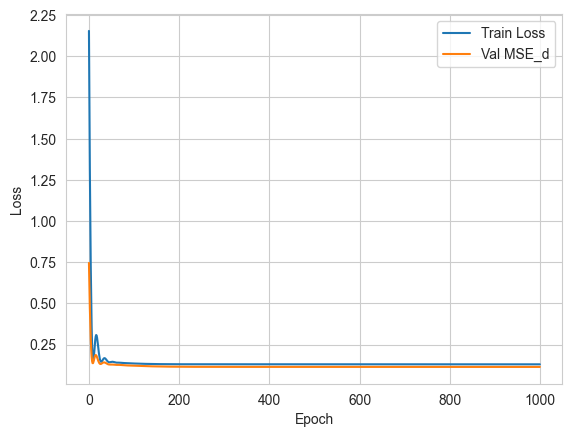

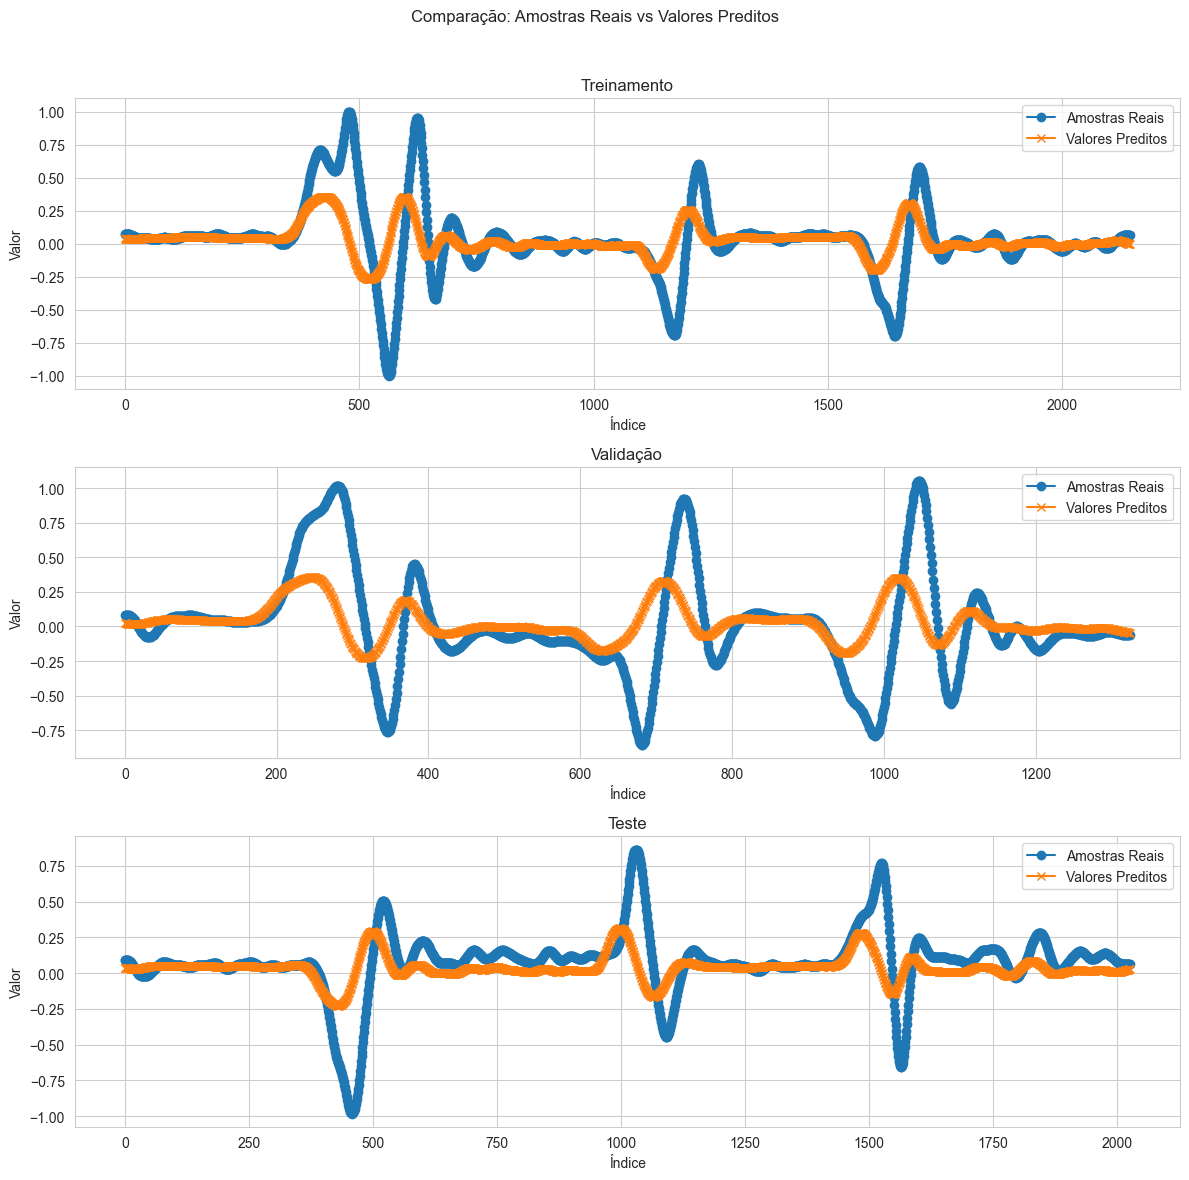

{'Training': {'R2': 0.16650772094726562,
  'MSE': 0.06418752670288086,
  'RMSE': 0.253352573902222,
  'MAPE': 2.1705760955810547},
 'Validation': {'R2': 0.17998242378234863,
  'MSE': 0.11414840817451477,
  'RMSE': 0.33785856238153084,
  'MAPE': 1.996492624282837},
 'Test': {'R2': 0.15528863668441772,
  'MSE': 0.04584840312600136,
  'RMSE': 0.21412240220491027,
  'MAPE': 1.03830087184906}}

In [28]:
import os
import random

#os.environ['PYTHONHASHSEED'] = '47'
#os.environ['TF_DETERMINISTIC_OPS'] = '1'  # força operações determinísticas no TF (em CPU/GPU)
#random.seed(47)
#np.random.seed(47)
#tf.random.set_seed(47)


model_pinn = keras.Sequential([
    keras.layers.Input(shape=(len(PREDICTORS),)),
    keras.layers.Dense(20, activation='tanh'),
    keras.layers.Dense(1)
])


# Extrai o valor MÍNIMO aprendido dos dados de treino
y_min_numpy = y_scaler.data_min_
# Extrai o FATOR DE ESCALA aprendido
y_scale_numpy = y_scaler.scale_
# Converte esses valores para constantes do TensorFlow para usar no laço
Y_min_tf = tf.constant(y_min_numpy, dtype=tf.float32)
Y_scale_tf = tf.constant(y_scale_numpy, dtype=tf.float32)

custom_train_model_with_es_physics(model_pinn,
                                       train_x = train_x_norm, train_y = train_y_norm,
                                       x_val = x_val_norm, y_val = y_val_norm,
                                       x_test = x_test_norm, y_test = y_test_norm,
                                       restrictions_data = Restrictions_data,
                                       Ts = 0.07, L = 0.123, R = 0.034,
                                       y_min= Y_min_tf, y_scaler= y_scaler,
                                       lambda1=1, lambda2=1,
                                       epochs = 1000, patience=40,
                                       min_delta=0, plot=True,
                                       learning_rate=0.01, use_early_stopping=True)

#Epoch 1: Loss=0.3381, MSE_d=0.3381, MSE_f=0.339, Val MSE=0.2454

c:\Users\João Vitor\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Treinando com Ts=0.07, L=0.123, R=0.034, λ1=1.0, λ2=0
Epoch 1: Loss=0.08057, MSE_d=0.08057, MSE_f=0.08092, Val MSE=0.2093
Epoch 50: Loss=0.06017, MSE_d=0.06017, MSE_f=0.06622, Val MSE=0.1043
Epoch 100: Loss=0.05716, MSE_d=0.05716, MSE_f=0.06334, Val MSE=0.1004
Epoch 150: Loss=0.0547, MSE_d=0.0547, MSE_f=0.06115, Val MSE=0.09727
Epoch 200: Loss=0.05208, MSE_d=0.05208, MSE_f=0.05857, Val MSE=0.09399
Epoch 250: Loss=0.04838, MSE_d=0.04838, MSE_f=0.05463, Val MSE=0.0888
Epoch 300: Loss=0.04828, MSE_d=0.04828, MSE_f=0.05325, Val MSE=0.08411
Epoch 350: Loss=0.0413, MSE_d=0.0413, MSE_f=0.0471, Val MSE=0.08012
Epoch 400: Loss=0.0372, MSE_d=0.0372, MSE_f=0.04286, Val MSE=0.07341
Epoch 450: Loss=0.03522, MSE_d=0.03522, MSE_f=0.04046, Val MSE=0.07089
Epoch 500: Loss=0.02977, MSE_d=0.02977, MSE_f=0.03507, Val MSE=0.0613
Epoch 550: Loss=0.02809, MSE_d=0.02809, MSE_f=0.03332, Val MSE=0.05955
Epoch 600: Loss=0.02389, MSE_d=0.02389, MSE_f=0.0292, Val MSE=0.04703
Epoch 650: Loss=0.01574, MSE_d=0.01574,

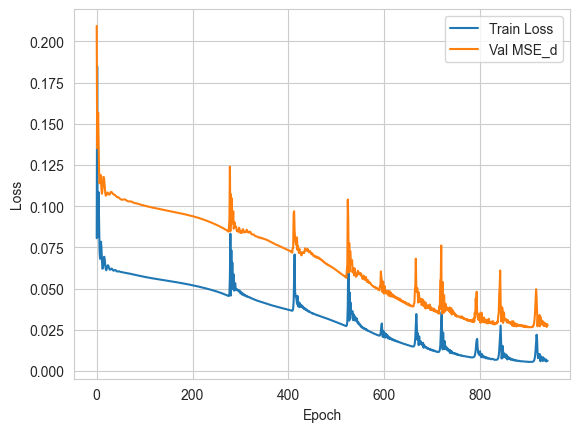

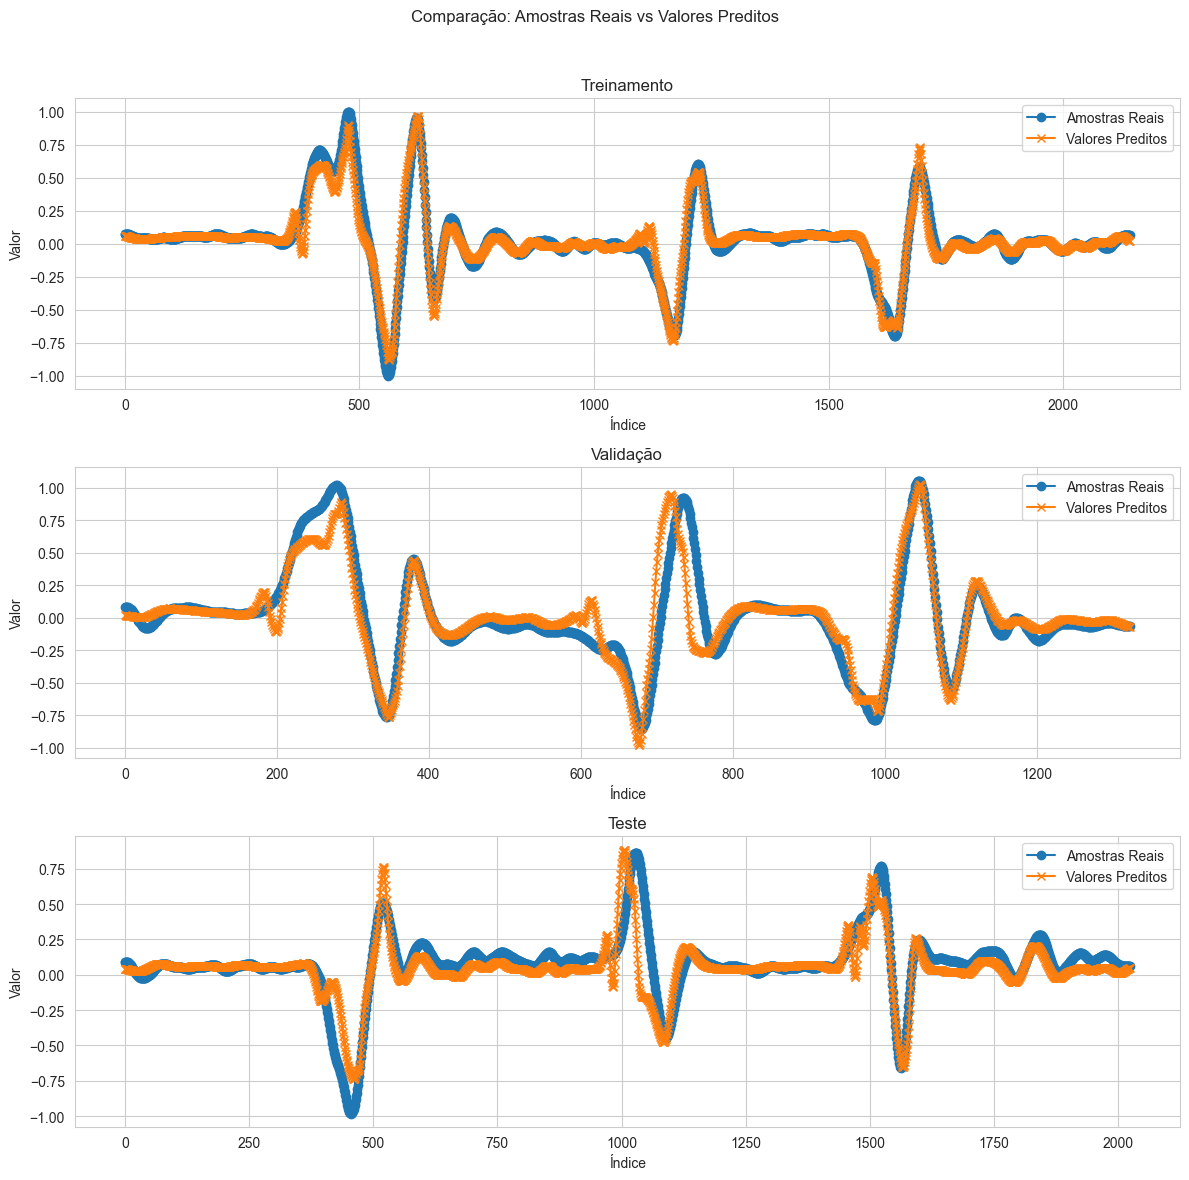

{'Training': {'R2': 0.9280192852020264,
  'MSE': 0.005548291373997927,
  'RMSE': 0.07448685369914564,
  'MAPE': 1.7923424243927002},
 'Validation': {'R2': 0.8099343180656433,
  'MSE': 0.02649609185755253,
  'RMSE': 0.16277620175428756,
  'MAPE': 1.8657101392745972},
 'Test': {'R2': 0.6528675556182861,
  'MSE': 0.018859826028347015,
  'RMSE': 0.13733108179995895,
  'MAPE': 0.9620017409324646}}

In [40]:
def create_sequences(input_data, target_data, timesteps):
    """
    Cria sequências de dados para treinamento de RNN.

    Args:
        input_data (np.array): Dados de entrada (X), formato (samples, features).
        target_data (np.array): Dados de saída (Y), formato (samples, target_features).
        timesteps (int): O número de passos de tempo passados a serem considerados.

    Returns:
        X_seq (np.array): Dados de entrada sequenciais, formato (N, timesteps, features).
        Y_seq (np.array): Dados de saída correspondentes, formato (N, target_features).
    """
    X_seq, Y_seq = [], []
    
    # Itera sobre os dados, começando após o número de timesteps
    for i in range(timesteps, len(input_data)):
        # A sequência de entrada (X_seq) é a janela de dados de i-timesteps até i
        X_seq.append(input_data[i-timesteps:i])
        
        # O alvo (Y_seq) é o valor de saída no passo de tempo atual 'i'
        Y_seq.append(target_data[i])
    
    return np.array(X_seq), np.array(Y_seq)


TIMESTEPS = 2
FEATURES = 2


model_pirrn = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[TIMESTEPS, FEATURES]),
    keras.layers.SimpleRNN(5, return_sequences= False),
    keras.layers.Dense(1)
])
train_x_seq, train_y_seq = create_sequences(train_x_norm, train_y_norm, TIMESTEPS)
x_val_seq, y_val_seq = create_sequences(x_val_norm, y_val_norm, TIMESTEPS)
x_test_seq, y_test_seq = create_sequences(x_test_norm, y_test_norm, TIMESTEPS)
custom_train_model_with_es_physics(model_pirrn,
                                       train_x = train_x_seq, train_y = train_y_seq,
                                       x_val = x_val_seq, y_val = y_val_seq,
                                       x_test = x_test_seq, y_test = y_test_seq,
                                       restrictions_data = Restrictions_data[:-2,:],
                                       Ts = 0.07, L = 0.123, R = 0.034,
                                       y_min= 0, y_scaler= y_scaler,
                                       lambda1=1.0, lambda2=0,
                                       epochs = 10000, patience=40,
                                       min_delta=0, plot=True,
                                       learning_rate=0.01, use_early_stopping=True)



67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


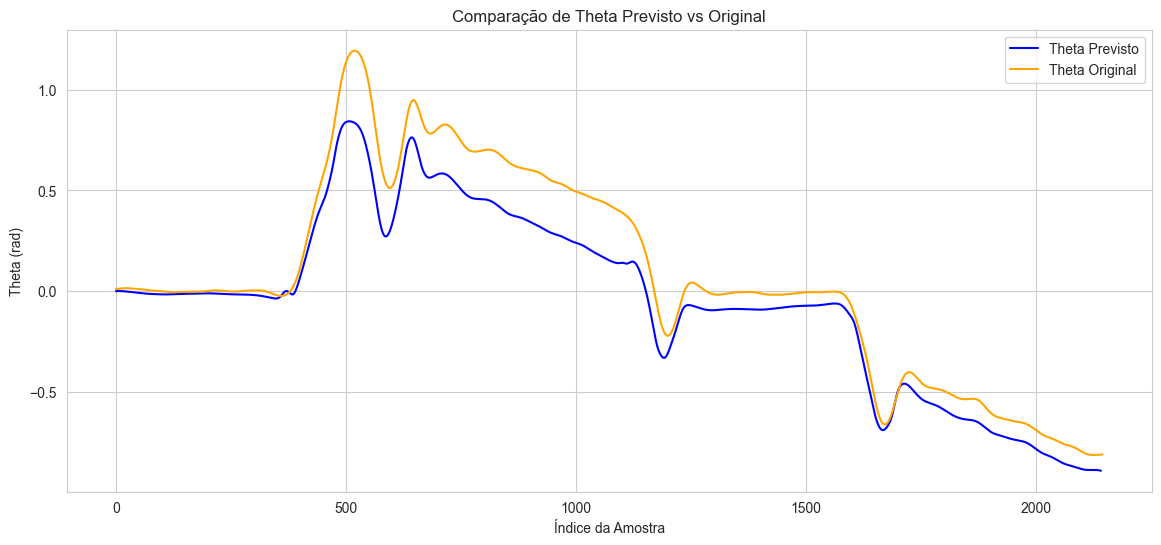

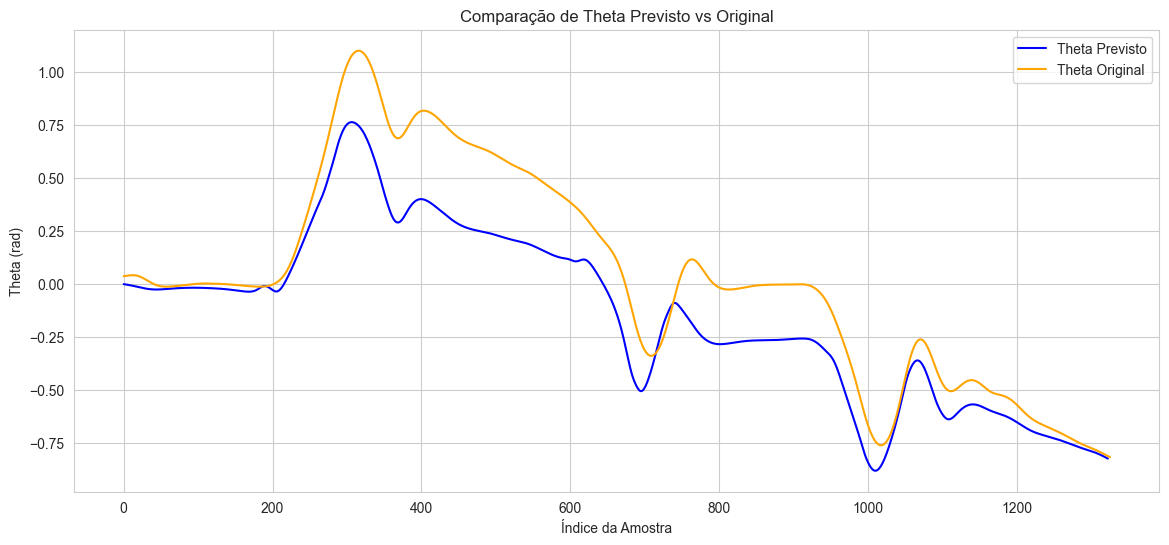

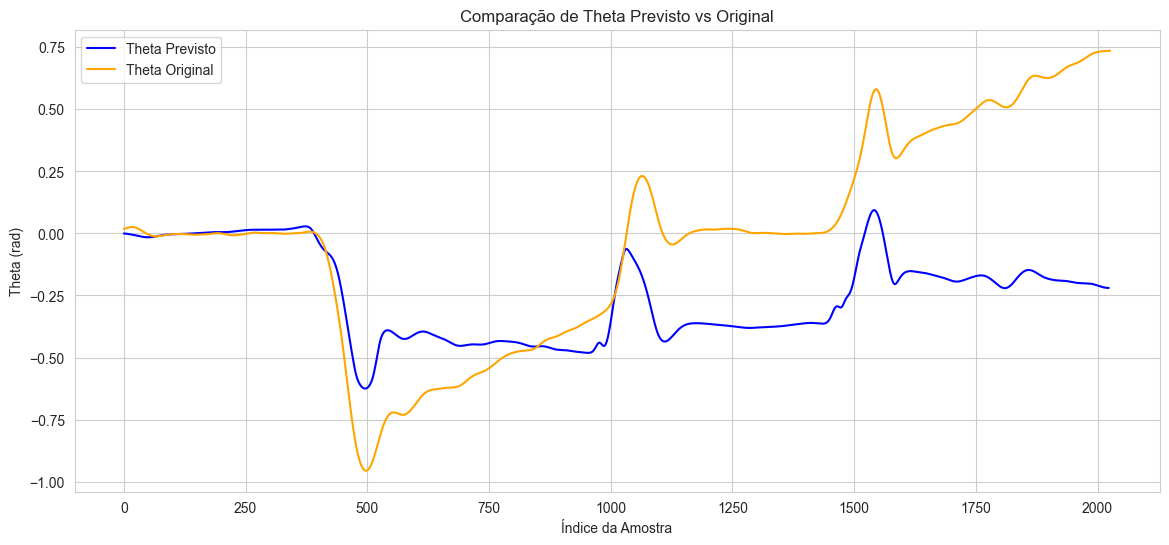

In [69]:
def Recontruir_Theta(model, inputs_norm, local_data_original, y_scaler):
    Y_norm = model.predict(inputs_norm)
    Y = y_scaler.inverse_transform(Y_norm)
    DataOrigi = pd.read_csv(local_data_original)
    Theta_Train = DataOrigi["theta(Wd,We)"].to_numpy()
    theta_rs = np.zeros((len(Y_norm), 1))
    theta_rs[0] = 0 # Wd_true do primeiro ponto
    for i in range(len(Y_norm)):
        theta_rs[i] = theta_rs[i-1] + Y[i] * 0.07  # Incrementa o ângulo com base na previsão

    plt.figure(figsize=(14, 6))
    plt.plot(theta_rs, label='Theta Previsto', color='blue')
    plt.plot(Theta_Train, label='Theta Original', color='orange')
    plt.xlabel('Índice da Amostra')
    plt.ylabel('Theta (rad)')
    plt.title('Comparação de Theta Previsto vs Original')
    plt.legend()



Recontruir_Theta(model_pirrn, train_x_seq, "./Dados/DataSmoothSpline1.csv", y_scaler)
Recontruir_Theta(model_pirrn, x_val_seq, "./Dados/DataSmoothSpline2.csv", y_scaler)
Recontruir_Theta(model_pirrn, x_test_seq, "./Dados/DataSmoothSpline3.csv", y_scaler)
    

In [30]:
model_pirrn2 = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[TIMESTEPS, FEATURES]),
    keras.layers.SimpleRNN(5, return_sequences= False),
    keras.layers.Dense(1)
])

custom_train_model_with_es_physics(model_pirrn2,
                                       train_x = train_x_seq, train_y = train_y_seq,
                                       x_val = x_val_seq, y_val = y_val_seq,
                                       x_test = x_test_seq, y_test = y_test_seq,
                                       restrictions_data = Restrictions_data[:-2,:],
                                       Ts = 0.07, L = 0.123, R = 0.034,
                                       y_min= 0, y_scaler= y_scaler,
                                       lambda1=0, lambda2=1.0,
                                       epochs = 10000, patience=80,
                                       min_delta=0, plot=True,
                                       learning_rate=0.01, use_early_stopping=True)

NameError: name 'TIMESTEPS' is not defined

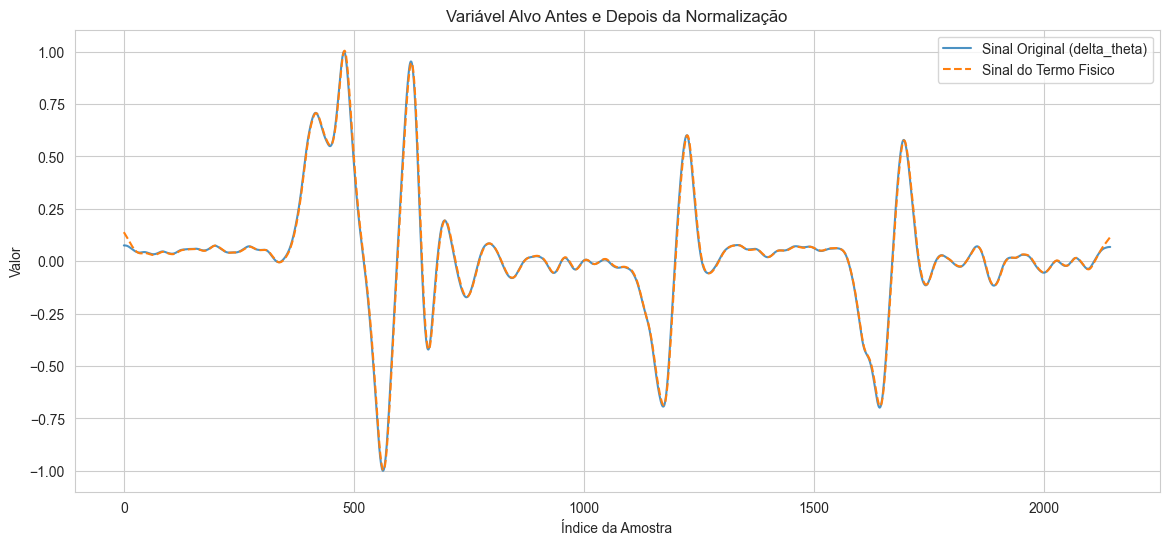

In [29]:

R = 0.034
L = 0.123
x1_km1 = Restrictions_data[:, 0]   # Wd
x2_km1 = Restrictions_data[:, 1]  # We

phys_real  = ((R / L) * (Restrictions_data[:, 0] - Restrictions_data[:, 1])) 
phys_real = phys_real.reshape(-1, 1)
phys_real_norm = y_scaler.transform(phys_real)
phys_data = ((R / L) * (train_x[:, 0] - train_x[:, 1])) 
phys_data_norm = y_scaler.transform(phys_data.reshape(-1, 1))

#print("Shape de phys_real:", phys_real.shape)
#print("Shape de train_y:", train_y.shape)

plt.figure(figsize=(14, 6))
plt.plot(train_y_norm, label='Sinal Original (delta_theta)', alpha=0.8)
plt.plot(phys_real_norm, label='Sinal do Termo Fisico', linestyle='--')
#plt.plot(phys_data_norm, label='Sinal Obtido por Odometria Setpoint', linestyle='--')
plt.title('Variável Alvo Antes e Depois da Normalização')
plt.xlabel('Índice da Amostra')
plt.ylabel('Valor')
plt.legend()
plt.show()